In [ ]:
#Upload and Load Dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('orders.csv')

df.head()

Saving orders.csv to orders (5).csv


,order_id,customer_id,order_date,category,region,revenue,quantity
0,1001,C0103,2024-01-01 00:00:00,Sports,East,215,1
1,1002,C0436,2024-01-01 01:00:00,Home,South,749,3
2,1003,C0349,2024-01-01 02:00:00,Fashion,South,391,4
3,1004,C0271,2024-01-01 03:00:00,Sports,South,531,3
4,1005,C0107,2024-01-01 04:00:00,Fashion,North,68,4


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy import stats

plt.style.use('ggplot')

In [ ]:
#Data Preparation
df['order_date'] = pd.to_datetime(df['order_date'])

print(df.shape)
print(df.info())
print(df.isnull().sum())


(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     5000 non-null   int64         
 1   customer_id  5000 non-null   object        
 2   order_date   5000 non-null   datetime64[ns]
 3   category     5000 non-null   object        
 4   region       5000 non-null   object        
 5   revenue      5000 non-null   int64         
 6   quantity     5000 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 273.6+ KB
None
order_id       0
customer_id    0
order_date     0
category       0
region         0
revenue        0
quantity       0
dtype: int64


In [ ]:
#KPI Dashboard
total_revenue = df['revenue'].sum()
total_orders = len(df)
total_customers = df['customer_id'].nunique()
avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 2642762
Total Orders: 5000
Total Customers: 500
Average Order Value: 528.55


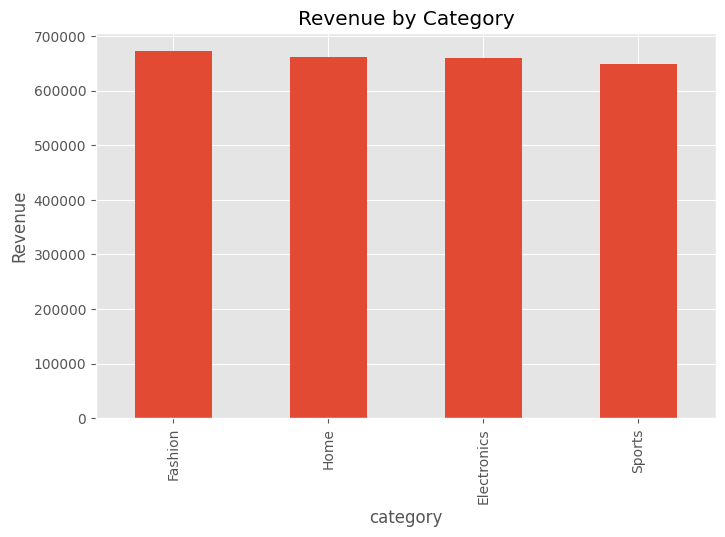

category
Fashion        672027
Home           661888
Electronics    659601
Sports         649246
Name: revenue, dtype: int64


In [ ]:
#Revenue by Category
category_sales = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.ylabel('Revenue')
plt.show()

print(category_sales)

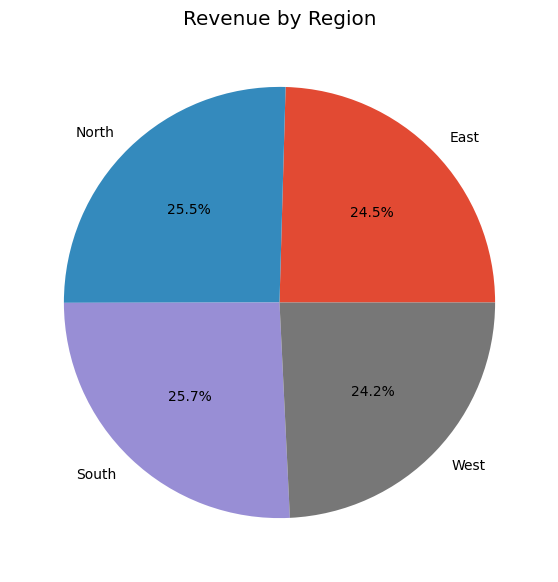

In [ ]:
#Revenue by Region
region_sales = df.groupby('region')['revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%')

plt.title('Revenue by Region')
plt.show()

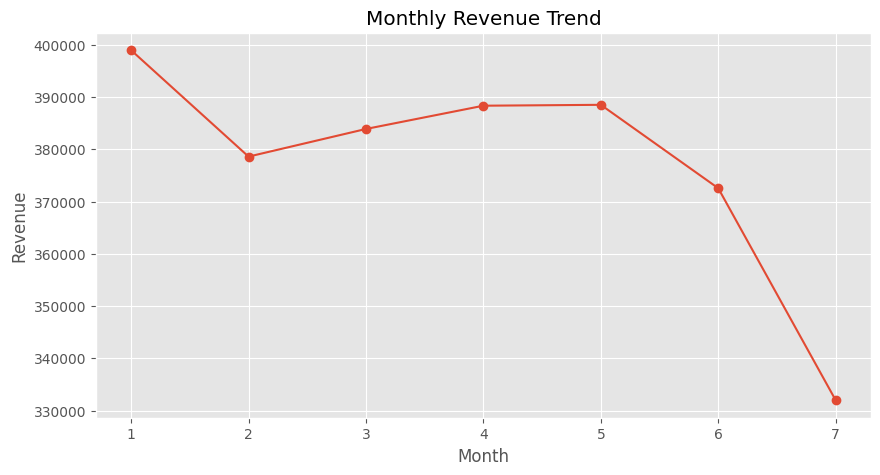

In [ ]:
#Monthly Revenue Trend
monthly_sales = df.groupby(df['order_date'].dt.month)['revenue'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

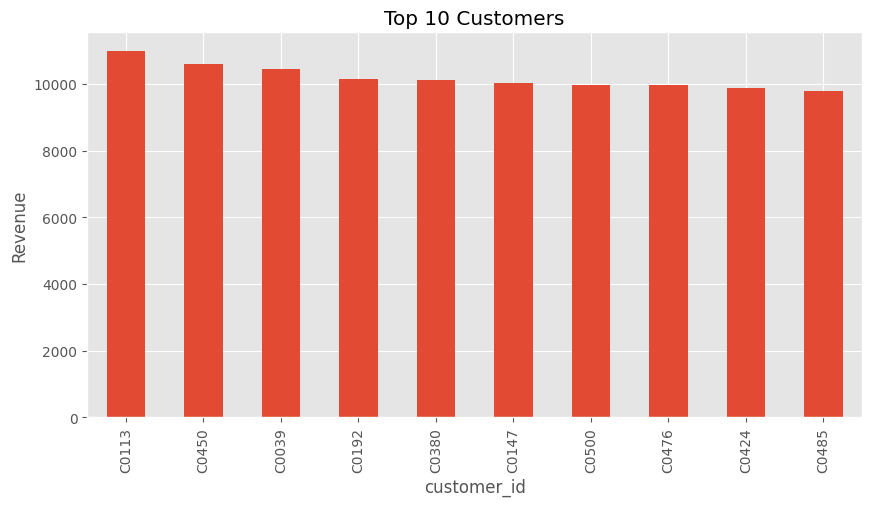

In [ ]:
#Top Customers
top_customers = (
    df.groupby('customer_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers")
plt.ylabel("Revenue")

plt.show()

## Statistical Validation
### Hypothesis
### Null Hypothesis (H₀)

Fashion category average revenue equals Electronics category average revenue.

### Alternative Hypothesis (H₁)

Fashion category average revenue differs from Electronics category average revenue.

In [ ]:
#T-Test
fashion = df[df['category']=='Fashion']['revenue']

electronics = df[df['category']=='Electronics']['revenue']

t_stat, p_value = ttest_ind(
    fashion,
    electronics,
    equal_var=False
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 0.5147831182390314
P Value: 0.6067501792978383


In [ ]:
#Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Significant Difference Exists")
else:
    print("Fail to Reject H0")
    print("No Significant Difference Found")

Fail to Reject H0
No Significant Difference Found


In [ ]:
#Confidence Interval
mean = fashion.mean()
std = fashion.std()
n = len(fashion)

ci = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=mean,
    scale=std/np.sqrt(n)
)

print("95% Confidence Interval:")
print(ci)

95% Confidence Interval:
(np.float64(520.4278417975912), np.float64(551.3855553315954))
